# 253. Can a search put a human ELM motif on its ortholog, in chicken and seven farther species?

A call **covers** a motif when the human side of the call holds at least 80% of the
motif's residues. Covering a motif with a call to *some* protein is easy. Each human query
keeps its best 1_000 target proteins, and most motifs sit inside a longer domain that many
proteins share. So the question asked here is narrower. Take a human protein with a 1:1
ortholog in the target species: the same OMA group, one member in each species. Did the
search put the motif on the ortholog, **at the place where the motif sits in the ortholog**?

"At the place" is measured against a protein alignment made without any of these
searches. [Notebook 250](https://github.com/seanome/2024-kmerseek-analysis/blob/olgabot/elm-cover-all-species/notebooks/250_elm_motif_transfer.ipynb) (Stage 0) aligned each human protein to its ortholog with MAFFT.
The motif's residues, carried through that alignment, give a stretch of ortholog
residues: the **projected motif**. A call to the ortholog is **on position** when its
target side holds at least 80% of the projected motif. A higher share of motifs on
position is better.

Inputs: 2_160 experimentally supported human ELM instances on 1_303 proteins, searched
against whole QfO 2020_04 proteomes.

- **Chicken** (sections 1 to 11): every kmerseek setting, 276 in all, and eight comparison
  tools. Of the 2_160 motifs, 550 are on a protein with a chicken ortholog, and 540 of those
  have a projected motif.
- **Seven farther species** (sections 12 to 16): mouse, zebrafish, the sea squirt Ciona, fly,
  worm, yeast and Arabidopsis, with the same eight comparison tools and the 19 kmerseek
  settings chosen on chicken, one per alphabet ([PR #72](https://github.com/seanome/2024-kmerseek-analysis/pull/72)). Sherlock run `run-elm-search-all`,
  29 September to 1 October 2026, image `docker.io/olgabot/kmerseek:0.4.0-rc5`.

Decision rule for the seven species, the one sections 8 and 9 applied to chicken: kmerseek
adds something to motif transfer if, in some species, at least one of its 19 settings puts
motifs on position that none of the eight comparison tools does. If no species has such a
motif, kmerseek adds nothing to these tools here.

Two corrections apply to every section. Foldseek and Reseek search AlphaFold models, so
they are scored only on motifs whose human query and ortholog both have a model matching
their QfO sequence (section 12). Reseek's target positions are corrected for an offset that
`bin/normalize_reseek.awk` adds to some accessions (section 13).

The scores come from `scripts/reduce_elm_cover.py`, one run per search, on Sherlock
(`make reduce-elm-cover` and `make reduce-elm-cover-all`). Its tests are in
`nextflow-runs/qfo-pfam-region-benchmark/tests/test_reduce_elm_cover.py`.

In [1]:
import json
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import elm_motif_utils as emu

pl.Config.set_tbl_rows(60)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

COVER = Path(
    os.environ.get("ELM_COVER_DIR", "/Users/olga/data/elm-motif-transfer/cover/chicken")
)
CONF = Path("../nextflow-runs/qfo-pfam-region-benchmark/conf/elm_cover.config")
ASSETS = Path("../nextflow-runs/qfo-pfam-region-benchmark/assets")
FIG = Path("../figures")
TAB = Path("../tables")

COMPARATORS = {
    "hmmer3_phmmer": "phmmer",
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "mmseqs2_iterative": "MMseqs2, iterative",
    "hhblits": "HHblits",
    "foldseek": "Foldseek",
    "prostt5": "Foldseek with ProstT5",
    "reseek": "Reseek",
}
ARM_RE = re.compile(
    r"^(?P<alphabet>.+)\.k(?P<k>\d+)(?:\.s(?P<scaled>\d+))?\.lc(?P<mask>true|false)$"
)


def parse_arm(arm):
    if arm in COMPARATORS:
        return {
            "tool": COMPARATORS[arm],
            "alphabet": None,
            "k": None,
            "scaled": None,
            "mask": None,
        }
    m = ARM_RE.match(arm)
    return {
        "tool": "kmerseek",
        "alphabet": m["alphabet"],
        "k": int(m["k"]),
        "scaled": int(m["scaled"] or 1),
        "mask": m["mask"] == "true",
    }


def arm_label(arm):
    p = parse_arm(arm)
    if p["tool"] != "kmerseek":
        return p["tool"]
    return (
        f"kmerseek {p['alphabet']}, k = {p['k']}, scaled {p['scaled']}, "
        f"mask {'on' if p['mask'] else 'off'}"
    )


PROJECTIONS = pl.read_csv(ASSETS / "elm_cover_projections.tsv", separator="\t")
MODEL_STATUS = pl.read_csv(emu.MODEL_STATUS_FILE, separator="\t")


def summary_frame(summaries):
    """One row per search, with its tool, alphabet, k, scaled and mask parsed from the name."""
    return pl.DataFrame(
        [
            {
                **{k: v for k, v in s.items() if k != "length_check"},
                "spearman_vs_length": (s.get("length_check") or {}).get(
                    "spearman_vs_length"
                ),
                **parse_arm(s["arm"]),
            }
            for s in summaries
        ],
        infer_schema_length=None,
    )


# Reseek is read from the corrected files (section 13); Foldseek and Reseek rows whose
# ortholog has no matching AlphaFold model are marked not scoreable (section 12).
summaries, I = emu.load_cover_scores(
    COVER.name, PROJECTIONS, MODEL_STATUS, cover_dir=COVER.parent
)
S = summary_frame(summaries)
I = I.join(S.select("arm", "tool", "alphabet", "k", "scaled", "mask"), on="arm")
print(
    f"{S.height} searches with a summary: {S['status'].value_counts().sort('status').rows()}"
)
print("Motifs left out of each tool's share, because it could not have put them on position:")
print(
    I.filter(pl.col("tool") != "kmerseek")
    .group_by("tool")
    .agg(
        query_model_not_qfo=(~pl.col("query_scoreable")).sum(),
        ortholog_model_missing_or_not_qfo=(
            pl.col("query_scoreable") & ~pl.col("scoreable")
        ).sum(),
    )
    .filter(pl.col("query_model_not_qfo") + pl.col("ortholog_model_missing_or_not_qfo") > 0)
    .sort("tool")
)
print(
    f"{I['elm_instance'].n_unique()} ELM instances; {I.filter('has_ortholog')['elm_instance'].n_unique()} on a protein "
    f"with a chicken ortholog; {I.filter('has_projection')['elm_instance'].n_unique()} with a projected motif"
)

276 searches with a summary: [('empty', 2), ('ok', 274)]
Motifs left out of each tool's share, because it could not have put them on position:
shape: (2, 3)
┌──────────┬─────────────────────┬───────────────────────────────────┐
│ tool     ┆ query_model_not_qfo ┆ ortholog_model_missing_or_not_qfo │
│ ---      ┆ ---                 ┆ ---                               │
│ str      ┆ u32                 ┆ u32                               │
╞══════════╪═════════════════════╪═══════════════════════════════════╡
│ Foldseek ┆ 106                 ┆ 267                               │
│ Reseek   ┆ 106                 ┆ 267                               │
└──────────┴─────────────────────┴───────────────────────────────────┘
2160 ELM instances; 550 on a protein with a chicken ortholog; 540 with a projected motif


## 1. How long ELM motifs are

Motif length is End - Start + 1 in the ELM instance table (ELM 1.4, downloaded 2026-09-24).
The database rows are every true-positive instance, from all organisms. The tested motifs are
the 540 human instances with a projected motif on the chicken ortholog.


shape: (3, 9)
┌───────────────┬──────┬───────────┬────────┬────────┬────────┬──────────┬──────────┬──────────┐
│ set           ┆ n    ┆ median aa ┆ 25% aa ┆ 75% aa ┆ max aa ┆ 3-6 aa   ┆ 7-10 aa  ┆ 11+ aa   │
│ ---           ┆ ---  ┆ ---       ┆ ---    ┆ ---    ┆ ---    ┆ ---      ┆ ---      ┆ ---      │
│ str           ┆ i64  ┆ f64       ┆ f64    ┆ f64    ┆ i64    ┆ f64      ┆ f64      ┆ f64      │
╞═══════════════╪══════╪═══════════╪════════╪════════╪════════╪══════════╪══════════╪══════════╡
│ ELM, all true ┆ 4047 ┆ 6.0       ┆ 5.0    ┆ 8.0    ┆ 47     ┆ 0.512231 ┆ 0.367927 ┆ 0.119842 │
│ positives     ┆      ┆           ┆        ┆        ┆        ┆          ┆          ┆          │
│ ELM, human    ┆ 2270 ┆ 7.0       ┆ 5.0    ┆ 8.0    ┆ 47     ┆ 0.492952 ┆ 0.400441 ┆ 0.106608 │
│ tested here   ┆ 540  ┆ 7.0       ┆ 5.0    ┆ 8.0    ┆ 29     ┆ 0.487037 ┆ 0.411111 ┆ 0.101852 │
│ (chicken      ┆      ┆           ┆        ┆        ┆        ┆          ┆          ┆          │
│ ortholog)     

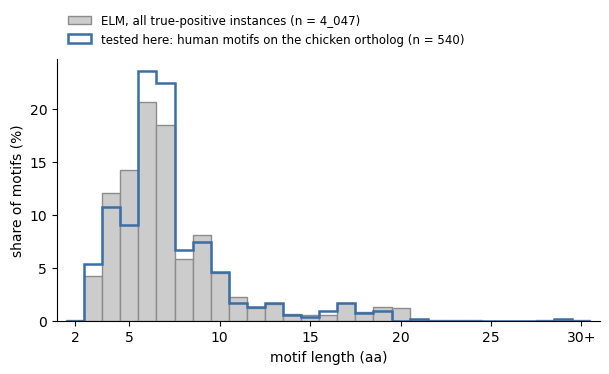

In [2]:
ELM = pl.read_csv(
    COVER.parent.parent / "elm_instances.tsv",
    separator="\t",
    comment_prefix="#",
    infer_schema_length=0,
).filter(pl.col("InstanceLogic") == "true positive").with_columns(
    motif_length=pl.col("End").cast(pl.Int64) - pl.col("Start").cast(pl.Int64) + 1
)
tested_ids = I.filter("has_projection")["elm_instance"].unique()
groups = {
    "ELM, all true positives": ELM,
    "ELM, human": ELM.filter(pl.col("Organism") == "Homo sapiens"),
    "tested here (chicken ortholog)": ELM.filter(pl.col("Accession").is_in(tested_ids.implode())),
}
LEN = pl.DataFrame(
    [
        {
            "set": name,
            "n": d.height,
            "median aa": d["motif_length"].median(),
            "25% aa": d["motif_length"].quantile(0.25),
            "75% aa": d["motif_length"].quantile(0.75),
            "max aa": d["motif_length"].max(),
            "3-6 aa": (d["motif_length"] <= 6).mean(),
            "7-10 aa": d["motif_length"].is_between(7, 10).mean(),
            "11+ aa": (d["motif_length"] >= 11).mean(),
        }
        for name, d in groups.items()
    ]
)
print(LEN)
by_type = (
    ELM.group_by("ELMType")
    .agg(n=pl.len(), median_aa=pl.col("motif_length").median(), max_aa=pl.col("motif_length").max())
    .sort("n", descending=True)
)
print("By ELM type (all true positives): CLV cleavage, DEG degradation, DOC docking, LIG ligand binding, MOD modification, TRG targeting")
print(by_type)
LEN.write_csv(TAB / "253_motif_lengths.csv")

fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.arange(1.5, 31.5, 1)
all_len = groups["ELM, all true positives"]["motif_length"].to_numpy()
test_len = groups["tested here (chicken ortholog)"]["motif_length"].to_numpy()
w_all = np.full(len(all_len), 100 / len(all_len))
w_test = np.full(len(test_len), 100 / len(test_len))
ax.hist(all_len.clip(max=30), bins=bins, weights=w_all, color="0.8", edgecolor="0.55",
        label=f"ELM, all true-positive instances (n = {len(all_len):_})")
ax.hist(test_len.clip(max=30), bins=bins, weights=w_test, histtype="step", lw=1.8, color="#3B6EA5",
        label=f"tested here: human motifs on the chicken ortholog (n = {len(test_len)})")
ax.set_xlim(1, 31)
ax.set_xticks([2, 5, 10, 15, 20, 25, 30], ["2", "5", "10", "15", "20", "25", "30+"])
ax.set_xlabel("motif length (aa)")
ax.set_ylabel("share of motifs (%)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8.5)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_motif_lengths.png", dpi=200, bbox_inches="tight")


ELM motifs are short. Over all 4_047 true-positive instances the median is 6 aa, half are 3-6 aa
(51%), and 12% are 11 aa or longer; the longest is a 47 aa ligand-binding (LIG) motif. The 540 tested
here have the same shape as the 2_270 human instances: median 7 aa, 49% at 3-6 aa, 10% at 11 aa or
longer.


## 2. Which kmerseek settings ran

A kmerseek setting is an alphabet, a k-mer length k, the low-complexity mask off or on, and
scaled 1, 2, 5 or 10. Scaled s keeps about one k-mer in s from the chicken proteome, so the
index is smaller. The settings that should exist are read from the search's own
configuration. So a setting that never wrote a result shows up here as missing, not as a
setting that found nothing. The eight comparison tools are listed after them.

In [3]:
conf = CONF.read_text()
combos = re.search(r"kmerseek_combos\s*=\s*'([^']+)'", conf)[1].split(",")
scaled_set = [
    int(x) for x in re.search(r"kmerseek_scaled\s*=\s*'([^']+)'", conf)[1].split(",")
]
masks = re.search(r"low_complexity_toggle\s*=\s*'([^']+)'", conf)[1].split(",")
expected = pl.DataFrame(
    [
        {"alphabet": a, "k": int(k), "scaled": s, "mask": m == "true"}
        for a, k in (c.split(":") for c in combos)
        for s in scaled_set
        for m in masks
    ]
)
km = S.filter(pl.col("tool") == "kmerseek").select(
    "alphabet", "k", "scaled", "mask", "status"
)
arms = expected.join(
    km, on=["alphabet", "k", "scaled", "mask"], how="left"
).with_columns(pl.col("status").fill_null("no result file"))
status = arms.group_by("status").len().sort("status")
print(f"kmerseek settings in the configuration: {expected.height}")
print(status)
print("\nSettings without a usable result:")
print(arms.filter(pl.col("status") != "ok").sort("alphabet", "k", "scaled", "mask"))
comp = S.filter(pl.col("tool") != "kmerseek").select("tool", "status").sort("tool")
print("\nComparison tools:")
print(comp)
arms.write_csv(TAB / "253_arm_status.csv")

kmerseek settings in the configuration: 272
shape: (3, 2)
┌────────────────┬─────┐
│ status         ┆ len │
│ ---            ┆ --- │
│ str            ┆ u32 │
╞════════════════╪═════╡
│ empty          ┆ 2   │
│ no result file ┆ 4   │
│ ok             ┆ 266 │
└────────────────┴─────┘

Settings without a usable result:
shape: (6, 5)
┌─────────────┬─────┬────────┬───────┬────────────────┐
│ alphabet    ┆ k   ┆ scaled ┆ mask  ┆ status         │
│ ---         ┆ --- ┆ ---    ┆ ---   ┆ ---            │
│ str         ┆ i64 ┆ i64    ┆ bool  ┆ str            │
╞═════════════╪═════╪════════╪═══════╪════════════════╡
│ funcgroups8 ┆ 7   ┆ 1      ┆ false ┆ empty          │
│ funcgroups8 ┆ 7   ┆ 1      ┆ true  ┆ empty          │
│ gbmr7       ┆ 10  ┆ 1      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 2      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 5      ┆ false ┆ no result file │
│ gbmr7       ┆ 10  ┆ 10     ┆ false ┆ no result file │
└─────────────┴─────┴────────┴───────┴──────────────

## 3. Covering a motif is easy; putting it on position is not

Each check below is stricter than the one before it. The **placement check** is from
notebook 250. Drop a window the same length as the call at a random place on the human
protein: how often does it also cover the motif? A call passes when that happens less than
5% of the time. The check looks at the human side only. So a long alignment of a whole
ortholog fails it even when it is right, because a window that long covers the motif
wherever it is dropped. The on-position check does not have that problem: it asks where
the call sits on the chicken side.

Share of motifs passing each check (kmerseek: the one setting with the highest on-position share):
shape: (9, 5)
┌───────────────────┬───────────────────┬───────────────────┬───────────────────┬──────────────────┐
│ tool              ┆ covered, any      ┆ covered, on the   ┆ covered on the    ┆ on the ortholog, │
│ ---               ┆ chicken protein   ┆ ortholog (of 550) ┆ ortholog, passes  ┆ on position (of  │
│ str               ┆ (of 2_160)        ┆ ---               ┆ the placement     ┆ 540)             │
│                   ┆ ---               ┆ f64               ┆ check (of 550)    ┆ ---              │
│                   ┆ f64               ┆                   ┆ ---               ┆ f64              │
│                   ┆                   ┆                   ┆ f64               ┆                  │
╞═══════════════════╪═══════════════════╪═══════════════════╪═══════════════════╪══════════════════╡
│ Reseek            ┆ 1.0               ┆ 0.964029          ┆ 0.0              

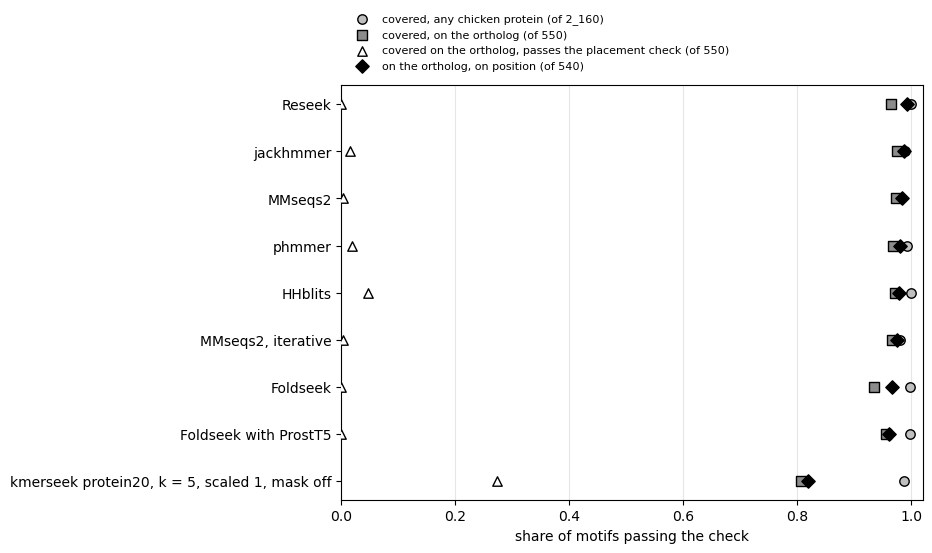

In [4]:
def shares(frame):
    frame = frame.filter("scoreable")
    orth = frame.filter("has_ortholog")
    proj = frame.filter("has_projection")
    return {
        "covered, any chicken protein (of 2_160)": frame["best_rank"]
        .is_not_null()
        .mean(),
        "covered, on the ortholog (of 550)": orth["ortholog_rank"].is_not_null().mean(),
        "covered on the ortholog, passes the placement check (of 550)": orth[
            "ortholog_rank_placed"
        ]
        .is_not_null()
        .mean(),
        "on the ortholog, on position (of 540)": proj["ortholog_rank_on_position"]
        .is_not_null()
        .mean(),
    }


ok = S.filter(pl.col("status") == "ok")["arm"].to_list()
rows = []
for arm in ok:
    rows.append({"arm": arm, **shares(I.filter(pl.col("arm") == arm))})
SH = pl.DataFrame(rows).join(
    S.select("arm", "tool", "alphabet", "k", "scaled", "mask"), on="arm"
)
CHECKS = [c for c in SH.columns if c.startswith(("covered", "on the"))]
best_km = (
    SH.filter(pl.col("tool") == "kmerseek")
    .sort(CHECKS[-1], "arm", descending=[True, False])
    .head(1)
)
show = pl.concat(
    [
        SH.filter(pl.col("tool") != "kmerseek").sort(CHECKS[-1], descending=True),
        best_km.with_columns(
            tool=pl.col("arm").map_elements(arm_label, return_dtype=pl.String)
        ),
    ]
)
print(
    "Share of motifs passing each check (kmerseek: the one setting with the highest on-position share):"
)
print(show.select("tool", *CHECKS))
show.select("tool", *CHECKS).write_csv(TAB / "253_checks_by_tool.csv")

markers = ["o", "s", "^", "D"]
fills = ["0.75", "0.55", "white", "black"]
fig, ax = plt.subplots(figsize=(7.5, 0.42 * show.height + 1.6))
labels = show["tool"].to_list()
for j, c in enumerate(CHECKS):
    ax.scatter(
        show[c],
        range(show.height),
        marker=markers[j],
        s=46,
        facecolor=fills[j],
        edgecolor="black",
        zorder=3,
        label=c,
    )
ax.set_yticks(range(show.height), labels)
ax.invert_yaxis()
ax.set_xlim(0, 1.02)
ax.set_xlabel("share of motifs passing the check")
ax.grid(axis="x", color="0.9", zorder=0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=1, frameon=False, fontsize=8)
fig.savefig(FIG / "253_checks_by_tool.png", dpi=200, bbox_inches="tight")

Every tool covers almost every motif with a call to *some* chicken protein (97% to 100%), so that check says nothing. The placement check rejects almost every correct call. For the six sequence tools, 0% to 5% of motifs pass it, while 96% to 99% are on position.

On position, the six sequence tools reach 96.1% (Foldseek with ProstT5) to 98.7% (jackhmmer). Foldseek reaches 96.6% and Reseek 99.3% of the 268 motifs they could reach. The other 272 motifs are left out for them: for 271 the chicken ortholog has no AlphaFold model in the run's structure folder, and for the rest the query's or the ortholog's model is not its QfO sequence (section 12). Why 156 of the 331 chicken orthologs have no model there is not checked here. The best kmerseek setting, protein20 with k = 5 at scaled 1, puts 442 of 540 motifs on position (81.9%).

## 4. Every kmerseek arm, on position

One point per kmerseek arm at scaled 1 (the full chicken index). Shape is the k-mer
length: each alphabet was run at two k (the shorter one only where the search fit in
memory, notebook 250 step 5). Filled means the low-complexity mask was off, open means on.
The comparison tools, from section 2, are the grey rows at the top.

kmerseek at scaled 1, share on position (of 540):
shape: (65, 4)
┌──────────────────────────┬─────┬───────┬───────────────────────────────────────┐
│ alphabet                 ┆ k   ┆ mask  ┆ on the ortholog, on position (of 540) │
│ ---                      ┆ --- ┆ ---   ┆ ---                                   │
│ str                      ┆ i64 ┆ bool  ┆ f64                                   │
╞══════════════════════════╪═════╪═══════╪═══════════════════════════════════════╡
│ dayhoff6                 ┆ 7   ┆ false ┆ 0.201852                              │
│ dayhoff6                 ┆ 7   ┆ true  ┆ 0.2                                   │
│ dayhoff6                 ┆ 9   ┆ false ┆ 0.627778                              │
│ dayhoff6                 ┆ 9   ┆ true  ┆ 0.627778                              │
│ funcgroups8              ┆ 6   ┆ false ┆ 0.492593                              │
│ funcgroups8              ┆ 6   ┆ true  ┆ 0.494444                              │
│ gbmr4               

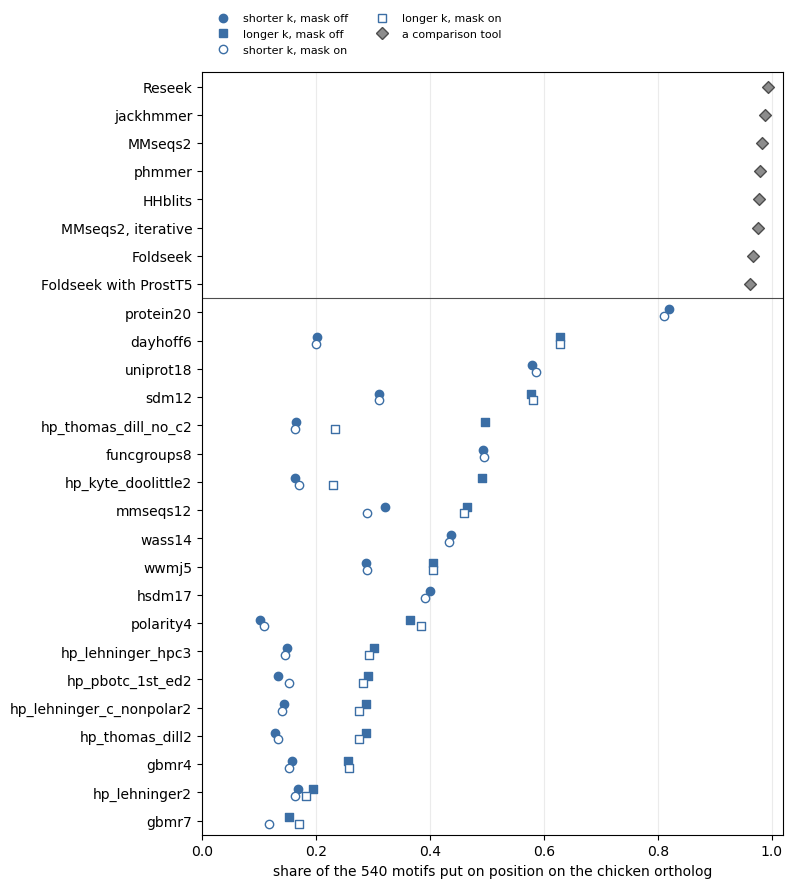

In [5]:
k1 = SH.filter((pl.col("tool") == "kmerseek") & (pl.col("scaled") == 1)).with_columns(
    k_rank=pl.col("k").rank("dense").over("alphabet")
)
order = (
    k1.group_by("alphabet")
    .agg(best=pl.col(CHECKS[-1]).max())
    .sort("best", "alphabet", descending=[True, False])["alphabet"]
    .to_list()
)
print("kmerseek at scaled 1, share on position (of 540):")
print(k1.select("alphabet", "k", "mask", CHECKS[-1]).sort("alphabet", "k", "mask"))
k1.select("alphabet", "k", "mask", *CHECKS).write_csv(TAB / "253_kmerseek_scaled1.csv")

comp_rows = SH.filter(pl.col("tool") != "kmerseek").sort(CHECKS[-1], descending=True)
names = comp_rows["tool"].to_list() + order
fig, ax = plt.subplots(figsize=(7.5, 0.3 * len(names) + 1.8))
for i, r in enumerate(comp_rows.iter_rows(named=True)):
    ax.scatter(
        r[CHECKS[-1]], i, marker="D", s=36, facecolor="0.55", edgecolor="0.3", zorder=3
    )
ax.axhline(comp_rows.height - 0.5, color="0.3", lw=0.8)
y = {a: comp_rows.height + i for i, a in enumerate(order)}
for r in k1.iter_rows(named=True):
    ax.scatter(
        r[CHECKS[-1]],
        y[r["alphabet"]] + (0.12 if r["mask"] else -0.12),
        marker="o" if r["k_rank"] == 1 else "s",
        s=36,
        facecolor="white" if r["mask"] else "#3B6EA5",
        edgecolor="#3B6EA5",
        zorder=3,
    )
ax.set_yticks(range(len(names)), names)
ax.set_ylim(len(names) - 0.5, -0.5)
ax.set_xlim(0, 1.02)
ax.set_xlabel("share of the 540 motifs put on position on the chicken ortholog")
handles = [
    plt.Line2D(
        [],
        [],
        marker="o",
        ls="",
        mfc="#3B6EA5",
        mec="#3B6EA5",
        label="shorter k, mask off",
    ),
    plt.Line2D(
        [],
        [],
        marker="s",
        ls="",
        mfc="#3B6EA5",
        mec="#3B6EA5",
        label="longer k, mask off",
    ),
    plt.Line2D(
        [],
        [],
        marker="o",
        ls="",
        mfc="white",
        mec="#3B6EA5",
        label="shorter k, mask on",
    ),
    plt.Line2D(
        [], [], marker="s", ls="", mfc="white", mec="#3B6EA5", label="longer k, mask on"
    ),
    plt.Line2D(
        [], [], marker="D", ls="", mfc="0.55", mec="0.3", label="a comparison tool"
    ),
]
ax.legend(
    handles=handles,
    loc="lower left",
    bbox_to_anchor=(0, 1.01),
    ncol=2,
    frameon=False,
    fontsize=8,
)
ax.grid(axis="x", color="0.92", zorder=0)
fig.savefig(FIG / "253_kmerseek_scaled1.png", dpi=200, bbox_inches="tight")

At scaled 1, the longer k puts more motifs on position in 27 of the 28 alphabet-and-mask pairs run at both k. For example, dayhoff6 reaches 20% at k = 7 and 63% at k = 9. The low-complexity mask changes the share by a median of 0.6 points. The two exceptions are hp_thomas_dill_no_c2 and hp_kyte_doolittle2 at k = 20, where the mask halves it (50% to 23%, and 49% to 23%). The hydrophobic-polar (HP) alphabets put 13% to 50% of the motifs on position at scaled 1.

## 5. Seed length k, per alphabet

The same arms as section 4, at scaled 1 with the mask off. Each alphabet ran at up to two k:
the shortest k whose seed occurs in fewer than 100 human proteins, and the shortest under 1_000
that fits the 128 GB search limit (notebook 250, `scripts/elm_seed_floor.py`). Five alphabets have
only one k. The right panel puts every alphabet on one axis: the bits in one seed,
k x log2(letters), so a 5-mer of 20 letters (21.6 bits) sits near a 22-mer of 2 letters (22 bits).


shape: (32, 5)
┌──────────────────────────┬─────────┬─────┬──────┬───────┐
│ alphabet                 ┆ letters ┆ k   ┆ bits ┆ share │
│ ---                      ┆ ---     ┆ --- ┆ ---  ┆ ---   │
│ str                      ┆ i64     ┆ i64 ┆ f64  ┆ f64   │
╞══════════════════════════╪═════════╪═════╪══════╪═══════╡
│ dayhoff6                 ┆ 6       ┆ 7   ┆ 18.1 ┆ 0.202 │
│ dayhoff6                 ┆ 6       ┆ 9   ┆ 23.3 ┆ 0.628 │
│ funcgroups8              ┆ 8       ┆ 6   ┆ 18.0 ┆ 0.493 │
│ gbmr4                    ┆ 4       ┆ 12  ┆ 24.0 ┆ 0.157 │
│ gbmr4                    ┆ 4       ┆ 14  ┆ 28.0 ┆ 0.256 │
│ gbmr7                    ┆ 7       ┆ 13  ┆ 36.5 ┆ 0.152 │
│ hp_kyte_doolittle2       ┆ 2       ┆ 17  ┆ 17.0 ┆ 0.163 │
│ hp_kyte_doolittle2       ┆ 2       ┆ 20  ┆ 20.0 ┆ 0.491 │
│ hp_lehninger2            ┆ 2       ┆ 15  ┆ 15.0 ┆ 0.169 │
│ hp_lehninger2            ┆ 2       ┆ 17  ┆ 17.0 ┆ 0.194 │
│ hp_lehninger_c_nonpolar2 ┆ 2       ┆ 15  ┆ 15.0 ┆ 0.144 │
│ hp_lehninger_c_nonpolar

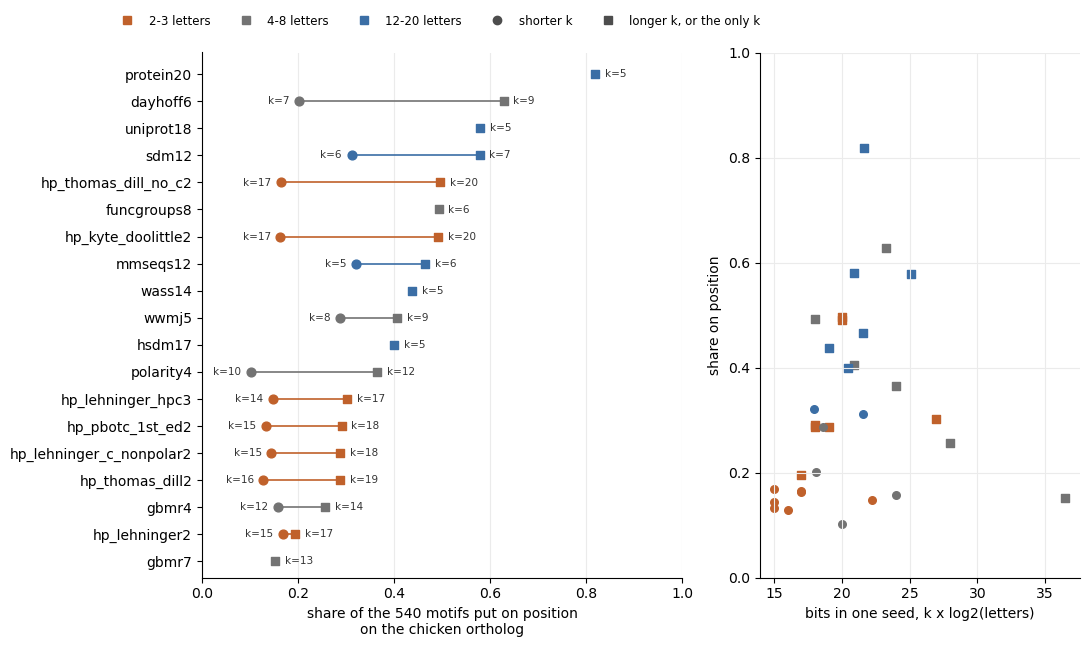

In [6]:
K1 = (
    k1.filter(~pl.col("mask"))
    .with_columns(letters=pl.col("alphabet").str.extract(r"(\d+)$").cast(pl.Int64))
    .with_columns(bits=pl.col("k") * pl.col("letters").log(2), share=pl.col(CHECKS[-1]))
    .sort("alphabet", "k")
)
print(K1.select("alphabet", "letters", "k", pl.col("bits").round(1), pl.col("share").round(3)))
K1.select("alphabet", "letters", "k", "bits", "share").write_csv(TAB / "253_seed_length.csv")

def size_group(n):
    return "2-3 letters" if n <= 3 else ("4-8 letters" if n <= 8 else "12-20 letters")
GROUP_COLOUR = {"2-3 letters": "#C0612B", "4-8 letters": "0.45", "12-20 letters": "#3B6EA5"}
K1 = K1.with_columns(group=pl.col("letters").map_elements(size_group, return_dtype=pl.String))
order_k = (
    K1.group_by("alphabet").agg(best=pl.col("share").max()).sort("best", descending=True)["alphabet"].to_list()
)
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 6.2), gridspec_kw={"width_ratios": [3, 2]})
for i, a in enumerate(order_k):
    d = K1.filter(pl.col("alphabet") == a).sort("k")
    col = GROUP_COLOUR[d["group"][0]]
    ax.plot(d["share"], [i] * d.height, color=col, lw=1.2, zorder=2)
    for j, r in enumerate(d.iter_rows(named=True)):
        shorter = j == 0 and d.height == 2
        ax.scatter(r["share"], i, marker="o" if shorter else "s", s=40, color=col, zorder=3)
        # shorter k labelled left of its point, longer k right, on the alphabet's own row
        ax.annotate(f"k={r['k']}", (r["share"], i), xytext=(-7 if shorter else 7, 0),
                    textcoords="offset points", ha="right" if shorter else "left",
                    va="center", fontsize=7.5, color="0.2")
ax.set_yticks(range(len(order_k)), order_k)
ax.set_ylim(len(order_k) - 0.4, -0.8)
ax.set_xlim(0, 1)
ax.set_xlabel("share of the 540 motifs put on position\non the chicken ortholog")
ax.grid(axis="x", color="0.92")
# same marks as the left panel: circle for the shorter k, square for the longer or only k
K1 = K1.with_columns(
    shorter=(pl.col("k") == pl.col("k").min().over("alphabet")) & (pl.len().over("alphabet") == 2)
)
for g, col in GROUP_COLOUR.items():
    for is_short, mk in [(True, "o"), (False, "s")]:
        d = K1.filter((pl.col("group") == g) & (pl.col("shorter") == is_short))
        bx.scatter(d["bits"], d["share"], color=col, marker=mk, s=30)
bx.set_xlabel("bits in one seed, k x log2(letters)")
bx.set_ylabel("share on position")
bx.set_ylim(0, 1)
bx.grid(color="0.92")
handles = [plt.Line2D([], [], color=c, marker="s", ls="", label=g) for g, c in GROUP_COLOUR.items()]
handles += [
    plt.Line2D([], [], color="0.3", marker="o", ls="", label="shorter k"),
    plt.Line2D([], [], color="0.3", marker="s", ls="", label="longer k, or the only k"),
]
fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.1, 0.99), ncol=5, frameon=False, fontsize=8.5)
for a_ in (ax, bx):
    for s in ["top", "right"]:
        a_.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG / "253_seed_length.png", dpi=200, bbox_inches="tight")


The longer k puts more motifs on position in all 13 alphabets run at two k (mask off). The gain
ranges from 2.5 points (hp_lehninger2, k = 15 to 17) to 43 points (dayhoff6, k = 7 to 9). Only two k
were run per alphabet, so this does not say where the share stops rising.

Bits per seed do not explain the order of the alphabets. At about 20-22 bits, protein20 k = 5 puts
82% on position, hp_thomas_dill_no_c2 k = 20 puts 50% and polarity4 k = 10 puts 10%. The alphabets
with 12 to 20 letters and dayhoff6 k = 9 are the top five settings (58% to 82%). The best HP settings reach
50% (hp_thomas_dill_no_c2 and hp_kyte_doolittle2 at k = 20); the other HP alphabets reach 19% to 30%.
Why the longer k helps is not tested here.

## 6. What a smaller index costs

For each kmerseek alphabet, k and mask, the on-position share at scaled 2, 5 and 10
divided by the share at scaled 1. A ratio of 1 means subsampling the chicken k-mers lost
nothing.

On-position share relative to scaled 1, over settings with a nonzero share at scaled 1:
shape: (3, 5)
┌────────┬────────┬──────────────┬──────────┬──────────┐
│ scaled ┆ n_arms ┆ median_ratio ┆ q25      ┆ q75      │
│ ---    ┆ ---    ┆ ---          ┆ ---      ┆ ---      │
│ i64    ┆ u32    ┆ f64          ┆ f64      ┆ f64      │
╞════════╪════════╪══════════════╪══════════╪══════════╡
│ 2      ┆ 65     ┆ 1.288591     ┆ 1.043956 ┆ 1.436508 │
│ 5      ┆ 65     ┆ 1.812785     ┆ 1.529412 ┆ 2.134969 │
│ 10     ┆ 65     ┆ 2.023121     ┆ 1.684932 ┆ 2.348684 │
└────────┴────────┴──────────────┴──────────┴──────────┘


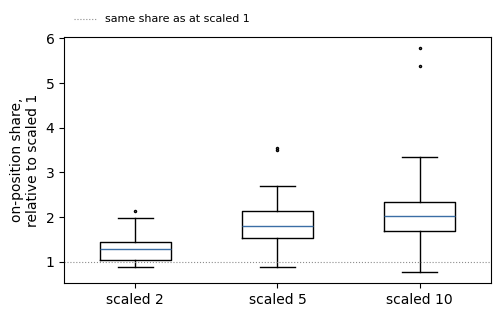

In [7]:
km_all = SH.filter(pl.col("tool") == "kmerseek")
base = km_all.filter(pl.col("scaled") == 1).select(
    "alphabet", "k", "mask", base=pl.col(CHECKS[-1])
)
ratio = (
    km_all.filter(pl.col("scaled") > 1)
    .join(base, on=["alphabet", "k", "mask"])
    .filter(pl.col("base") > 0)
    .with_columns(ratio=pl.col(CHECKS[-1]) / pl.col("base"))
)
summ = (
    ratio.group_by("scaled")
    .agg(
        n_arms=pl.len(),
        median_ratio=pl.col("ratio").median(),
        q25=pl.col("ratio").quantile(0.25),
        q75=pl.col("ratio").quantile(0.75),
    )
    .sort("scaled")
)
print(
    "On-position share relative to scaled 1, over settings with a nonzero share at scaled 1:"
)
print(summ)
summ.write_csv(TAB / "253_scaled_cost.csv")

if summ.is_empty():
    print(
        "No setting has both scaled 1 and a larger scaled with a result, so there is nothing to compare."
    )
else:
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    data = [
        ratio.filter(pl.col("scaled") == s)["ratio"].to_numpy() for s in summ["scaled"]
    ]
    ax.boxplot(
        data,
        tick_labels=[f"scaled {s}" for s in summ["scaled"]],
        widths=0.5,
        medianprops={"color": "#3B6EA5"},
        flierprops={"marker": ".", "markersize": 3},
    )
    ax.axhline(1, color="0.55", ls=":", lw=0.8, label="same share as at scaled 1")
    ax.set_ylabel("on-position share,\nrelative to scaled 1")
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
    fig.savefig(FIG / "253_scaled_cost.png", dpi=200, bbox_inches="tight")

Subsampling the chicken index raises the share instead of lowering it. The comparison uses the 65 alphabet, k and mask settings with a nonzero share at scaled 1. Against scaled 1, the median share is 1.29 times higher at scaled 2, 1.81 times at scaled 5 and 2.02 times at scaled 10.

This notebook does not explain it. Section 7 shows that kmerseek puts the ortholog low in the query's list. Section 11 shows that its ranking score follows call length. One reading is that a smaller index leaves fewer long calls to other proteins above the ortholog, before the cut to 1_000 targets. That reading is not tested here.

## 7. Rank of the ortholog, when it is on position

Rank is the ortholog's place in the query's list of chicken proteins, ordered by each
protein's best call: rank 1 means the ortholog was the best chicken hit. Shown for the
comparison tools and for the best kmerseek arm of section 2.

Motifs on position (of 540), by the ortholog's rank in the query's list:
shape: (9, 5)
┌─────────────────────────────────────────────┬─────────────┬────────┬──────────────┬──────────────┐
│ label                                       ┆ on_position ┆ rank_1 ┆ rank_2_to_10 ┆ rank_over_10 │
│ ---                                         ┆ ---         ┆ ---    ┆ ---          ┆ ---          │
│ str                                         ┆ u32         ┆ u32    ┆ u32          ┆ u32          │
╞═════════════════════════════════════════════╪═════════════╪════════╪══════════════╪══════════════╡
│ jackhmmer                                   ┆ 533         ┆ 491    ┆ 42           ┆ 0            │
│ MMseqs2                                     ┆ 531         ┆ 497    ┆ 34           ┆ 0            │
│ phmmer                                      ┆ 529         ┆ 492    ┆ 37           ┆ 0            │
│ HHblits                                     ┆ 528         ┆ 485    ┆ 43           ┆ 0            │
│ MM

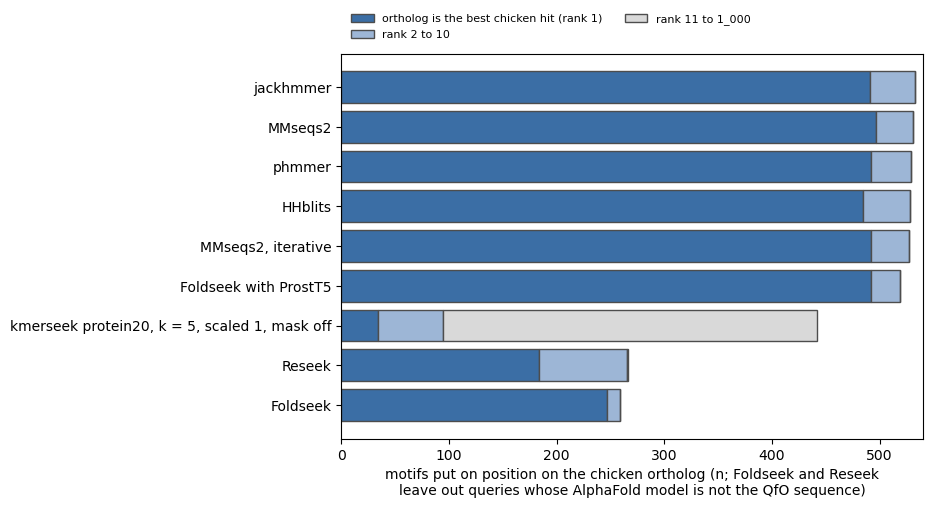

In [8]:
pick = (
    SH.filter(pl.col("tool") != "kmerseek")["arm"].to_list() + best_km["arm"].to_list()
)
R = I.filter(
    pl.col("arm").is_in(pick) & pl.col("has_projection") & pl.col("scoreable")
).with_columns(label=pl.col("arm").map_elements(arm_label, return_dtype=pl.String))
rk = (
    R.group_by("label")
    .agg(
        on_position=pl.col("ortholog_rank_on_position").is_not_null().sum(),
        rank_1=(pl.col("ortholog_rank_on_position") == 1).sum(),
        rank_2_to_10=pl.col("ortholog_rank_on_position").is_between(2, 10).sum(),
        rank_over_10=(pl.col("ortholog_rank_on_position") > 10).sum(),
    )
    .sort("on_position", descending=True)
)
print("Motifs on position (of 540), by the ortholog's rank in the query's list:")
print(rk)
rk.write_csv(TAB / "253_ortholog_rank.csv")

fig, ax = plt.subplots(figsize=(7.5, 0.4 * rk.height + 1.4))
left = np.zeros(rk.height)
for col, colour, name in [
    ("rank_1", "#3B6EA5", "ortholog is the best chicken hit (rank 1)"),
    ("rank_2_to_10", "#9DB6D6", "rank 2 to 10"),
    ("rank_over_10", "0.85", "rank 11 to 1_000"),
]:
    ax.barh(rk["label"], rk[col], left=left, color=colour, edgecolor="0.3", label=name)
    left += rk[col].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, R.group_by("label").len()["len"].max())
ax.set_xlabel(
    "motifs put on position on the chicken ortholog (n; Foldseek and Reseek\n"
    "leave out queries whose AlphaFold model is not the QfO sequence)"
)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False, fontsize=8)
fig.savefig(FIG / "253_ortholog_rank.png", dpi=200, bbox_inches="tight")

When a sequence tool puts the motif on position, the ortholog is its best chicken hit for 485 to 497 of 540 motifs, and never below rank 10. For the best kmerseek setting the ortholog is the best hit for 34 of its 442 motifs, and below rank 10 for 348 of them. Foldseek and Reseek rank the ortholog first for 247 of their 259 and 184 of their 266 motifs on position.

## 8. Motifs only kmerseek puts on position

A motif that no comparison tool puts on position, but at least one kmerseek setting does.
The first count pools every kmerseek setting, so it is an upper bound: with 266 settings,
some will land by chance. The second count uses only the best setting of section 3. That
setting was chosen on these same motifs, so its count is also optimistic.

motifs with a projected motif: 540
on position for at least one comparison tool: 537
on position for no comparison tool, but for at least one kmerseek setting: 0
  ... and for the best kmerseek setting (kmerseek protein20, k = 5, scaled 1, mask off): 0
shape: (0, 10)
┌──────────┬──────────┬──────────┬───────┬─────┬──────────┬──────────┬─────────┬─────────┬─────────┐
│ elm_inst ┆ elm_clas ┆ accessio ┆ start ┆ end ┆ motif_le ┆ length_b ┆ any_com ┆ n_km_ar ┆ best_ar │
│ ance     ┆ s        ┆ n        ┆ ---   ┆ --- ┆ ngth     ┆ in       ┆ parator ┆ ms      ┆ m       │
│ ---      ┆ ---      ┆ ---      ┆ i64   ┆ i64 ┆ ---      ┆ ---      ┆ ---     ┆ ---     ┆ ---     │
│ str      ┆ str      ┆ str      ┆       ┆     ┆ i64      ┆ str      ┆ bool    ┆ u32     ┆ bool    │
╞══════════╪══════════╪══════════╪═══════╪═════╪══════════╪══════════╪═════════╪═════════╪═════════╡
└──────────┴──────────┴──────────┴───────┴─────┴──────────┴──────────┴─────────┴─────────┴─────────┘


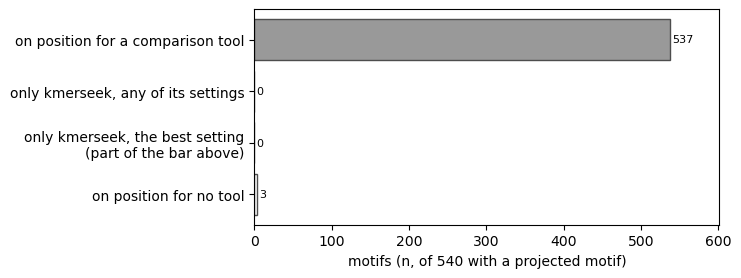

In [9]:
proj = I.filter("has_projection")
by_comp = (
    proj.filter(pl.col("tool") != "kmerseek")
    .group_by("elm_instance")
    .agg(any_comparator=pl.col("ortholog_rank_on_position").is_not_null().any())
)
by_km = (
    proj.filter(pl.col("tool") == "kmerseek")
    .group_by("elm_instance")
    .agg(n_km_arms=pl.col("ortholog_rank_on_position").is_not_null().sum())
)
by_best = proj.filter(pl.col("arm") == best_km["arm"][0]).select(
    "elm_instance", best_arm=pl.col("ortholog_rank_on_position").is_not_null()
)
U = (
    proj.select(
        "elm_instance",
        "elm_class",
        "accession",
        "start",
        "end",
        "motif_length",
        "length_bin",
    )
    .unique()
    .join(by_comp, on="elm_instance")
    .join(by_km, on="elm_instance")
    .join(by_best, on="elm_instance")
)
only_km = U.filter(~pl.col("any_comparator") & (pl.col("n_km_arms") > 0))
print(f"motifs with a projected motif: {U.height}")
print(f"on position for at least one comparison tool: {U['any_comparator'].sum()}")
print(
    f"on position for no comparison tool, but for at least one kmerseek setting: {only_km.height}"
)
print(
    f"  ... and for the best kmerseek setting ({arm_label(best_km['arm'][0])}): {only_km['best_arm'].sum()}"
)
print(only_km.sort("n_km_arms", descending=True).head(20))
only_km.write_csv(TAB / "253_only_kmerseek.csv")

fig, ax = plt.subplots(figsize=(6, 2.8))
vals = [
    U["any_comparator"].sum(),
    only_km.height,
    int(only_km["best_arm"].sum()),
    U.height - U["any_comparator"].sum() - only_km.height,
]
names = [
    "on position for a comparison tool",
    "only kmerseek, any of its settings",
    "only kmerseek, the best setting\n(part of the bar above)",
    "on position for no tool",
]
ax.barh(
    names,
    vals,
    color=["0.6", "#3B6EA5", "#3B6EA5", "white"],
    edgecolor="0.3",
    hatch=[None, None, "//", None],
)
for i, v in enumerate(vals):
    ax.text(v + 3, i, f"{v}", va="center", fontsize=8)
ax.invert_yaxis()
ax.set_xlim(0, 1.12 * max(vals))
ax.set_xlabel(f"motifs (n, of {U.height} with a projected motif)")
fig.savefig(FIG / "253_only_kmerseek.png", dpi=200, bbox_inches="tight")

537 of the 540 motifs are put on position by at least one comparison tool. No motif is put on position by a kmerseek setting and by none of the comparison tools, pooling all 266 settings.

## 9. Which tool's misses kmerseek places

For each comparison tool: the motifs it does not put on position, and how many of those the
best kmerseek setting of section 3 does. Foldseek and Reseek count only the 268 motifs whose
query and ortholog both have an AlphaFold model matching their QfO sequence. The kmerseek
setting was chosen on these same motifs, so its counts are an upper bound.

kmerseek setting: kmerseek protein20, k = 5, scaled 1, mask off
shape: (8, 6)
┌───────────────────────┬───────────┬────────┬─────────────┬────────┬──────────────────────────────┐
│ tool                  ┆ structure ┆ motifs ┆ on position ┆ missed ┆ missed, kmerseek on position │
│ ---                   ┆ ---       ┆ ---    ┆ ---         ┆ ---    ┆ ---                          │
│ str                   ┆ bool      ┆ i64    ┆ i64         ┆ i64    ┆ i64                          │
╞═══════════════════════╪═══════════╪════════╪═════════════╪════════╪══════════════════════════════╡
│ Reseek                ┆ true      ┆ 268    ┆ 266         ┆ 2      ┆ 0                            │
│ jackhmmer             ┆ false     ┆ 540    ┆ 533         ┆ 7      ┆ 0                            │
│ MMseqs2               ┆ false     ┆ 540    ┆ 531         ┆ 9      ┆ 0                            │
│ Foldseek              ┆ true      ┆ 268    ┆ 259         ┆ 9      ┆ 4                            │
│ phmmer     

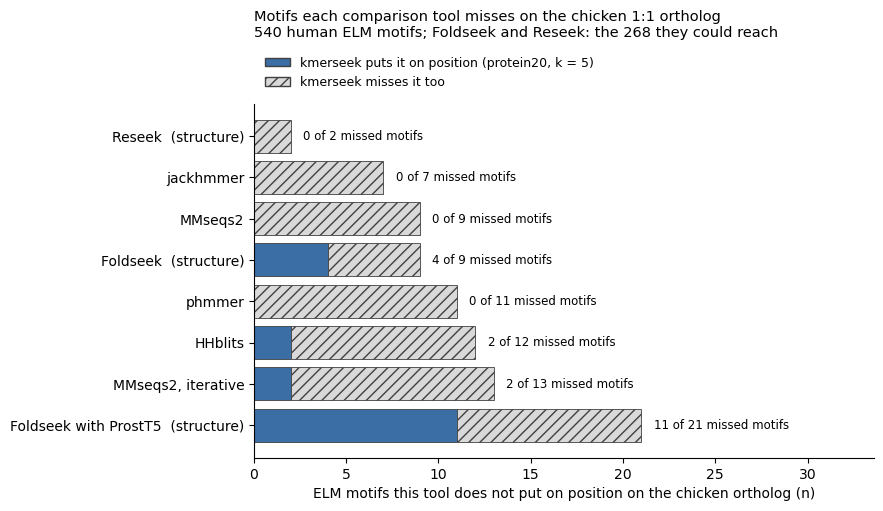

In [10]:
best_arm = best_km["arm"][0]
km_hit = proj.filter(pl.col("arm") == best_arm).select(
    "elm_instance", km=pl.col("ortholog_rank_on_position").is_not_null()
)
STRUCTURE = {"Foldseek", "Foldseek with ProstT5", "Reseek"}
rows = []
for arm, tool in COMPARATORS.items():
    t = (
        proj.filter((pl.col("arm") == arm) & pl.col("scoreable"))
        .with_columns(hit=pl.col("ortholog_rank_on_position").is_not_null())
        .join(km_hit, on="elm_instance")
    )
    miss = t.filter(~pl.col("hit"))
    rows.append(
        {
            "tool": tool,
            "structure": tool in STRUCTURE,
            "motifs": t.height,
            "on position": int(t["hit"].sum()),
            "missed": miss.height,
            "missed, kmerseek on position": int(miss["km"].sum()),
        }
    )
MISS = pl.DataFrame(rows).sort("missed")
print(f"kmerseek setting: {arm_label(best_arm)}")
print(MISS)
MISS.write_csv(TAB / "253_misses_by_tool.csv")

blue, grey = "#3B6EA5", "#D9D9D9"
fig, ax = plt.subplots(figsize=(8, 4.6))
y = range(MISS.height)
filled = MISS["missed, kmerseek on position"]
ax.barh(y, filled, color=blue, edgecolor="0.25", lw=0.6)
ax.barh(
    y,
    MISS["missed"] - filled,
    left=filled,
    color=grey,
    edgecolor="0.25",
    lw=0.6,
    hatch="///",
)
for i, r in enumerate(MISS.iter_rows(named=True)):
    ax.text(
        r["missed"] + 0.02 * 1.6 * MISS["missed"].max(),
        i,
        f"{r['missed, kmerseek on position']} of {r['missed']} missed motifs",
        va="center",
        fontsize=8.5,
    )
ax.set_yticks(
    list(y),
    [f"{t}  (structure)" if s else t for t, s in zip(MISS["tool"], MISS["structure"])],
)
ax.invert_yaxis()
ax.set_xlim(0, 1.6 * MISS["missed"].max())
ax.set_xlabel("ELM motifs this tool does not put on position on the chicken ortholog (n)")
ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, facecolor=blue, edgecolor="0.25",
                      label="kmerseek puts it on position (protein20, k = 5)"),
        plt.Rectangle((0, 0), 1, 1, facecolor=grey, edgecolor="0.25", hatch="///",
                      label="kmerseek misses it too"),
    ],
    loc="lower left",
    bbox_to_anchor=(0, 1.01),
    frameon=False,
    fontsize=9,
)
ax.set_title(
    "Motifs each comparison tool misses on the chicken 1:1 ortholog\n"
    "540 human ELM motifs; Foldseek and Reseek: the 268 they could reach",
    loc="left",
    fontsize=10.5,
    pad=48,
)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_misses_by_tool.png", dpi=200, bbox_inches="tight")

Every tool misses few motifs on chicken. Foldseek with ProstT5 misses the most, 21, and kmerseek puts 11 of those on position. Foldseek misses 9 and Reseek 2 of the motifs they could reach. The sequence alignment tools miss 7 to 13 each, and kmerseek places 0 to 2 of them. Each motif kmerseek places that one tool misses is placed by another comparison tool (section 8).

## 10. By motif length and disorder

Share of motifs put on position, split by motif length and by whether most of the motif is
disordered (`frac_disordered_motif` >= 0.5, from `elm_instance_covariates.parquet`). Four tools:
the two best sequence tools, Foldseek (on the 268 motifs it could reach), and the best kmerseek setting.

Share on position by length:
shape: (3, 5)
┌─────────┬───────────┬──────────┬───────────────────────────┬───────────┐
│ length  ┆ jackhmmer ┆ MMseqs2  ┆ kmerseek, protein20 k = 5 ┆ Foldseek  │
│ ---     ┆ ---       ┆ ---      ┆ ---                       ┆ ---       │
│ str     ┆ f64       ┆ f64      ┆ f64                       ┆ f64       │
╞═════════╪═══════════╪══════════╪═══════════════════════════╪═══════════╡
│ 11+ aa  ┆ 1.0       ┆ 1.0      ┆ 0.927273                  ┆ 1.0       │
│ 3-6 aa  ┆ 0.980989  ┆ 0.969582 ┆ 0.794677                  ┆ 0.9453125 │
│ 7-10 aa ┆ 0.990991  ┆ 0.995495 ┆ 0.81982                   ┆ 0.982609  │
└─────────┴───────────┴──────────┴───────────────────────────┴───────────┘
shape: (3, 2)
┌─────────┬─────┐
│ length  ┆ n   │
│ ---     ┆ --- │
│ str     ┆ u32 │
╞═════════╪═════╡
│ 11+ aa  ┆ 55  │
│ 3-6 aa  ┆ 263 │
│ 7-10 aa ┆ 222 │
└─────────┴─────┘
Share on position by disorder:
shape: (2, 5)
┌────────────┬───────────┬───────────────────────────┬───────

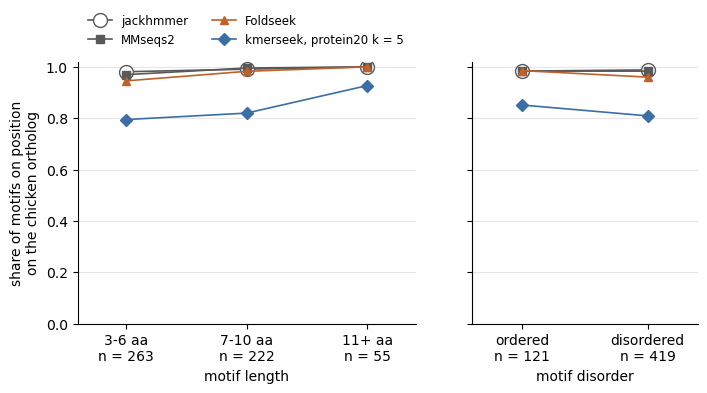

In [11]:
COV = pl.read_parquet(COVER.parent.parent / "elm_instance_covariates.parquet").select(
    "elm_instance", "frac_disordered_motif"
)
SHOW = {
    "hmmer3_jackhmmer": "jackhmmer",
    "mmseqs2_seqseq": "MMseqs2",
    "foldseek": "Foldseek",
    best_arm: "kmerseek, protein20 k = 5",
}
LB = (
    proj.filter(pl.col("arm").is_in(list(SHOW)) & pl.col("scoreable"))
    .join(COV, on="elm_instance", how="left")
    .with_columns(
        tool=pl.col("arm").replace_strict(SHOW),
        hit=pl.col("ortholog_rank_on_position").is_not_null(),
        length=pl.when(pl.col("motif_length") <= 6)
        .then(pl.lit("3-6 aa"))
        .when(pl.col("motif_length") <= 10)
        .then(pl.lit("7-10 aa"))
        .otherwise(pl.lit("11+ aa")),
        disorder=pl.when(pl.col("frac_disordered_motif") >= 0.5)
        .then(pl.lit("disordered"))
        .otherwise(pl.lit("ordered")),
    )
)
by = {}
for g, order in [("length", ["3-6 aa", "7-10 aa", "11+ aa"]), ("disorder", ["ordered", "disordered"])]:
    t = LB.group_by(g, "tool").agg(share=pl.col("hit").mean(), n=pl.len())
    by[g] = (t, order)
    print(f"Share on position by {g}:")
    print(t.pivot(on="tool", index=g, values="share").sort(g))
    print(t.filter(pl.col("tool") == "MMseqs2").select(g, "n").sort(g))
LB.group_by("length", "disorder", "tool").agg(share=pl.col("hit").mean(), n=pl.len()).sort(
    "length", "disorder", "tool"
).write_csv(TAB / "253_by_length_disorder.csv")

STYLE = {
    "jackhmmer": dict(color="0.35", marker="o", mfc="white", ms=10),
    "MMseqs2": dict(color="0.35", marker="s"),
    "Foldseek": dict(color="#C0612B", marker="^"),
    "kmerseek, protein20 k = 5": dict(color="#3B6EA5", marker="D"),
}
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), sharey=True, gridspec_kw={"width_ratios": [3, 2]})
for ax, (g, (t, order)) in zip(axes, by.items()):
    for tool, st in STYLE.items():
        d = t.filter(pl.col("tool") == tool)
        vals = [d.filter(pl.col(g) == o)["share"][0] for o in order]
        ax.plot(range(len(order)), vals, lw=1.2, label=tool, **{"ms": 6, **st})
    n = t.filter(pl.col("tool") == "MMseqs2")
    ax.set_xticks(
        range(len(order)),
        [f"{o}\nn = {n.filter(pl.col(g) == o)['n'][0]}" for o in order],
    )
    ax.set_xlim(-0.4, len(order) - 0.6)
    ax.grid(axis="y", color="0.9")
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylim(0, 1.02)
axes[0].set_ylabel("share of motifs on position\non the chicken ortholog")
axes[0].set_xlabel("motif length")
axes[1].set_xlabel("motif disorder")
axes[0].legend(loc="lower left", bbox_to_anchor=(0, 1.02), ncol=2, frameon=False, fontsize=8.5)
fig.savefig(FIG / "253_by_length_disorder.png", dpi=200, bbox_inches="tight")


kmerseek does worse on short and on disordered motifs, as every sequence tool does, and the gap to
MMseqs2 is widest on the shortest motifs (79.5% against 97.0% at 3-6 aa; 92.7% against 100% at
11+ aa). Foldseek puts 96.0% of the disordered motifs it could reach on position and 98.5% of the
ordered ones. On chicken, kmerseek is not better than the sequence tools on short or disordered
motifs. Chicken is close to human, so the sequence tools find nearly every ortholog here. Sections
12 to 16 test the farther species ([PR #72](https://github.com/seanome/2024-kmerseek-analysis/pull/72)).

## 11. Does the kmerseek score just follow call length?

For each kmerseek setting, this is the Spearman correlation between `region_mean_idf`, the
score that ranks its calls, and the call's length in residues. It uses a fixed sample of
about one call in 1_000. A score that tracks length ranks long calls first whatever they
match, which makes covering a motif easy for the wrong reason.

shape: (1, 4)
┌────────────┬──────────┬───────────┬─────────┐
│ n_settings ┆ median   ┆ min       ┆ max     │
│ ---        ┆ ---      ┆ ---       ┆ ---     │
│ u32        ┆ f64      ┆ f64       ┆ f64     │
╞════════════╪══════════╪═══════════╪═════════╡
│ 266        ┆ 0.795851 ┆ -0.179479 ┆ 0.92281 │
└────────────┴──────────┴───────────┴─────────┘


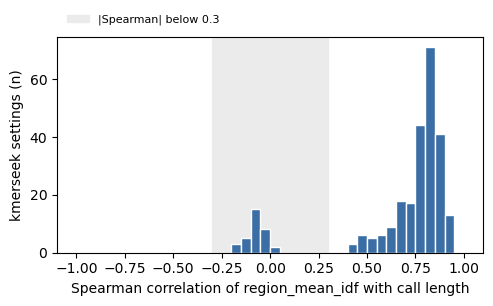

In [12]:
lc = S.filter(
    (pl.col("tool") == "kmerseek") & pl.col("spearman_vs_length").is_not_null()
)
print(
    lc.select(
        n_settings=pl.len(),
        median=pl.col("spearman_vs_length").median(),
        min=pl.col("spearman_vs_length").min(),
        max=pl.col("spearman_vs_length").max(),
    )
)
lc.select("arm", "spearman_vs_length").sort(
    "spearman_vs_length", descending=True
).write_csv(TAB / "253_length_check.csv")
fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.hist(
    lc["spearman_vs_length"],
    bins=np.linspace(-1, 1, 41),
    color="#3B6EA5",
    edgecolor="white",
)
ax.axvspan(-0.3, 0.3, color="0.92", zorder=0, label="|Spearman| below 0.3")
ax.set_xlabel("Spearman correlation of region_mean_idf with call length")
ax.set_ylabel("kmerseek settings (n)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
fig.savefig(FIG / "253_length_check.png", dpi=200, bbox_inches="tight")

`region_mean_idf` follows call length: the median Spearman correlation over the 266 kmerseek settings is 0.80 (lowest -0.18, highest 0.92). Longer calls rank first whatever they match, which fits the low rank of the ortholog in section 7.

## 12. Seven farther species: what was searched, and which motifs can be tested

Each of the seven species was searched with the eight comparison tools and the 19 kmerseek
settings chosen on chicken: for each alphabet, the setting that put the most chicken motifs on
position ([PR #72](https://github.com/seanome/2024-kmerseek-analysis/pull/72), `assets/elm_cover_chosen_arms.tsv`). Chicken is shown beside them with the
same 19 settings and tools. One difference: in the seven species, kmerseek kept each query's
best 1_000 target proteins inside the search; for chicken it kept everything and the scoring
made the same cut.

The bars count the human motifs with a projected position on each species' 1:1 ortholog, the
denominator of every share below. They are split by the ortholog's AlphaFold model. Foldseek
and Reseek can only reach the blue part: an ortholog without a model is not in their database,
and a model that is not the QfO sequence numbers its residues differently from the projected
motif. Those motifs are left out of Foldseek's and Reseek's shares, not counted as misses.

kmerseek settings run on all seven species: 19
shape: (8, 8)
┌────────────┬────────────┬────────────┬────────┬───────────┬────────────┬────────────┬────────────┐
│ species    ┆ kmerseek_o ┆ comparison ┆ motifs ┆ orthologs ┆ motifs_ort ┆ motifs_ort ┆ motifs_ort │
│ ---        ┆ k          ┆ _tools_ok  ┆ ---    ┆ ---       ┆ holog_mode ┆ holog_no_m ┆ holog_mode │
│ enum       ┆ ---        ┆ ---        ┆ u32    ┆ u32       ┆ l_matches  ┆ odel       ┆ l_differs  │
│            ┆ u32        ┆ u32        ┆        ┆           ┆ ---        ┆ ---        ┆ ---        │
│            ┆            ┆            ┆        ┆           ┆ u32        ┆ u32        ┆ u32        │
╞════════════╪════════════╪════════════╪════════╪═══════════╪════════════╪════════════╪════════════╡
│ mouse      ┆ 19         ┆ 8          ┆ 1343   ┆ 814       ┆ 1301       ┆ 40         ┆ 2          │
│ chicken    ┆ 19         ┆ 8          ┆ 540    ┆ 331       ┆ 268        ┆ 271        ┆ 1          │
│ zebrafish  ┆ 19         ┆ 8 

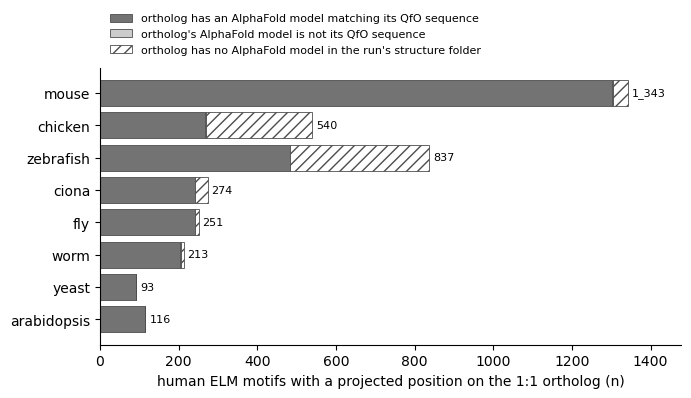

In [13]:
COMPARATOR_ARMS = list(COMPARATORS)
seven = [sp for sp in emu.COVER_SPECIES if sp != "chicken"]
per_species = {}
for sp in emu.COVER_SPECIES:
    sums, inst = emu.load_cover_scores(sp, PROJECTIONS, MODEL_STATUS, cover_dir=COVER.parent)
    per_species[sp] = (summary_frame(sums).with_columns(species=pl.lit(sp)), inst)
# The 19 kmerseek settings chosen on chicken (one per alphabet, notebook 250) are the
# kmerseek searches every one of the seven species has.
chosen_sets = {
    sp: set(per_species[sp][0].filter(pl.col("tool") == "kmerseek")["arm"]) for sp in seven
}
CHOSEN = sorted(set.intersection(*chosen_sets.values()))
assert all(s == set(CHOSEN) for s in chosen_sets.values()), "species ran different settings"
assert set(CHOSEN) <= set(S["arm"]), "a chosen setting is missing from chicken"
ALL_S = pl.concat([s for s, _ in per_species.values()], how="diagonal_relaxed")
ALL_I = pl.concat([i for _, i in per_species.values()], how="diagonal_relaxed").filter(
    pl.col("arm").is_in(COMPARATOR_ARMS + CHOSEN)
)
ran = (
    ALL_S.filter(pl.col("arm").is_in(COMPARATOR_ARMS + CHOSEN))
    .group_by("species")
    .agg(
        kmerseek_ok=((pl.col("tool") == "kmerseek") & (pl.col("status") == "ok")).sum(),
        comparison_tools_ok=((pl.col("tool") != "kmerseek") & (pl.col("status") == "ok")).sum(),
    )
)
one = ALL_I.filter(pl.col("arm") == "hmmer3_phmmer")
tested = (
    one.filter("has_projection")
    .group_by("species")
    .agg(
        motifs=pl.len(),
        orthologs=pl.col("ortholog").n_unique(),
        motifs_ortholog_model_matches=(pl.col("ortholog_model") == "same").sum(),
        motifs_ortholog_no_model=(pl.col("ortholog_model") == "no model").sum(),
        motifs_ortholog_model_differs=(pl.col("ortholog_model") == "differs").sum(),
    )
)
SPECIES_TABLE = (
    ran.join(tested, on="species")
    .with_columns(pl.col("species").cast(pl.Enum(emu.COVER_SPECIES)))
    .sort("species")
)
print(f"kmerseek settings run on all seven species: {len(CHOSEN)}")
print(SPECIES_TABLE)
SPECIES_TABLE.write_csv(TAB / "253_species_tested_motifs.csv")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
y = np.arange(SPECIES_TABLE.height)
left = np.zeros(SPECIES_TABLE.height)
for col, colour, hatch, name in [
    ("motifs_ortholog_model_matches", "0.45", None, "ortholog has an AlphaFold model matching its QfO sequence"),
    ("motifs_ortholog_model_differs", "0.8", None, "ortholog's AlphaFold model is not its QfO sequence"),
    ("motifs_ortholog_no_model", "white", "///", "ortholog has no AlphaFold model in the run's structure folder"),
]:
    v = SPECIES_TABLE[col].to_numpy()
    ax.barh(y, v, left=left, color=colour, hatch=hatch, edgecolor="0.3", lw=0.6, label=name)
    left += v
for yi, total in zip(y, left):
    ax.text(total + 10, yi, f"{int(total):_}", va="center", fontsize=8)
ax.set_yticks(y, SPECIES_TABLE["species"].cast(pl.String))
ax.invert_yaxis()
ax.set_xlim(0, 1.1 * left.max())
ax.set_xlabel("human ELM motifs with a projected position on the 1:1 ortholog (n)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_species_tested_motifs.png", dpi=200, bbox_inches="tight")


Every species has results for all 19 kmerseek settings and all eight comparison tools. The number
of motifs falls with distance, from 1_343 in mouse to 93 in yeast, because fewer of the human
proteins have a 1:1 ortholog there (814 orthologs in mouse, 71 in yeast). Chicken and zebrafish
are short of AlphaFold models: for 271 of 540 and 354 of 837 motifs the ortholog has no model in
the structure folder. In the other species it is 1 to 40 motifs.

## 13. Reseek positions, corrected

`bin/normalize_reseek.awk` turns Reseek's structure file names into accessions. An AlphaFold
model of a long protein is split into pieces named F1, F2 and so on, and the script adds 200
residues for each piece after the first. It reads the piece number from the first `-F` and
digits in the file name. For an accession that starts with F and a digit, that is the
accession: `AF-F6SXM4-F1.cif` is read as piece 6, and 1_000 is added to every position on
F6SXM4. The table counts, per species, the orthologs whose accession starts with F2 to F9.

`scripts/rescore_elm_reseek_offset.sh` subtracts that offset from a copy of each species'
Reseek table and rescores Reseek alone. Every other section uses the corrected scores. The
awk script itself is fixed in a separate change. Shown are the motifs Reseek could reach
(section 12).

Reseek, motifs whose ortholog has a matching AlphaFold model:
shape: (8, 7)
┌─────────────┬────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ species     ┆ motifs ┆ orthologs F2  ┆ on position, ┆ on position, ┆ pct_publishe ┆ pct_correcte │
│ ---         ┆ ---    ┆ to F9         ┆ as published ┆ corrected    ┆ d            ┆ d            │
│ str         ┆ i64    ┆ ---           ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│             ┆        ┆ i64           ┆ i64          ┆ i64          ┆ f64          ┆ f64          │
╞═════════════╪════════╪═══════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ mouse       ┆ 1297   ┆ 3             ┆ 1293         ┆ 1295         ┆ 99.7         ┆ 99.8         │
│ chicken     ┆ 268    ┆ 1             ┆ 263          ┆ 266          ┆ 98.1         ┆ 99.3         │
│ zebrafish   ┆ 481    ┆ 7             ┆ 472          ┆ 480          ┆ 98.1         ┆ 99.8         │
│ ciona       ┆

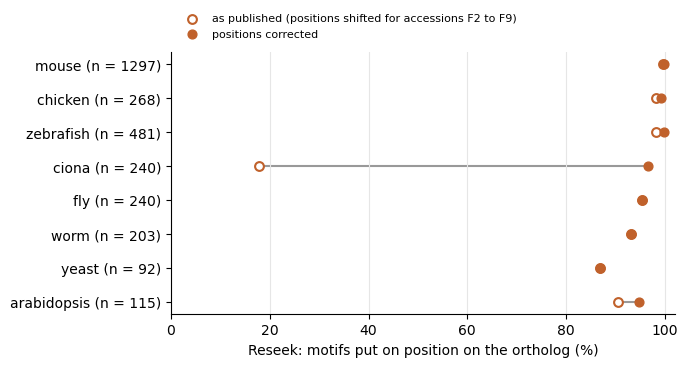

In [14]:
def on_position_share(inst):
    """Share of scoreable motifs with a projected position that are on position."""
    p = inst.filter(pl.col("has_projection") & pl.col("scoreable"))
    return p.height, int(p["ortholog_rank_on_position"].is_not_null().sum())


rows = []
for sp in emu.COVER_SPECIES:
    inst = per_species[sp][1]
    raw = (
        pl.read_parquet(COVER.parent / sp / "reseek.instances.parquet")
        .select("elm_instance", "ortholog_rank_on_position")
        .join(inst.filter(pl.col("arm") == "reseek").select("elm_instance", "has_projection", "scoreable"),
              on="elm_instance")
    )
    n, before = on_position_share(raw)
    _, after = on_position_share(inst.filter(pl.col("arm") == "reseek"))
    f_acc = MODEL_STATUS.filter((pl.col("species") == sp) & pl.col("ortholog").str.contains(r"^F[2-9]"))
    rows.append({"species": sp, "motifs": n, "orthologs F2 to F9": f_acc.height,
                 "on position, as published": before,
                 "on position, corrected": after})
RESEEK_FIX = pl.DataFrame(rows).with_columns(
    pct_published=100 * pl.col("on position, as published") / pl.col("motifs"),
    pct_corrected=100 * pl.col("on position, corrected") / pl.col("motifs"),
)
print("Reseek, motifs whose ortholog has a matching AlphaFold model:")
print(RESEEK_FIX.with_columns(pl.col("pct_published", "pct_corrected").round(1)))
RESEEK_FIX.write_csv(TAB / "253_reseek_position_correction.csv")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
y = np.arange(RESEEK_FIX.height)
ax.hlines(y, RESEEK_FIX["pct_published"], RESEEK_FIX["pct_corrected"], color="0.6", lw=1.5, zorder=1)
ax.scatter(RESEEK_FIX["pct_published"], y, s=40, facecolor="white", edgecolor="#C0612B", lw=1.5,
           zorder=2, label="as published (positions shifted for accessions F2 to F9)")
ax.scatter(RESEEK_FIX["pct_corrected"], y, s=40, color="#C0612B", zorder=3, label="positions corrected")
ax.set_yticks(y, [f"{s} (n = {n})" for s, n in zip(RESEEK_FIX["species"], RESEEK_FIX["motifs"])])
ax.invert_yaxis()
ax.set_xlim(0, 102)
ax.set_xlabel("Reseek: motifs put on position on the ortholog (%)")
ax.grid(axis="x", color="0.9", zorder=0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_reseek_position_correction.png", dpi=200, bbox_inches="tight")

129 of Ciona's 158 orthologs have an accession that starts with F2 to F9; the other species have 0 to 8. So the offset changed Reseek's share most on Ciona: 17.9% as published, 96.7% corrected. It moved Arabidopsis from 90.4% to 94.8%, chicken from 98.1% to 99.3% and zebrafish from 98.1% to 99.8%. Fly, worm and yeast, with no such orthologs, did not change, and mouse moved by 0.1 points.

## 14. On position, from mouse to Arabidopsis

The share of motifs each search puts on position on the 1:1 ortholog, in species from
closest to furthest from human. Higher is better. The grey band spans the five sequence
alignment tools (phmmer, jackhmmer, MMseqs2 in two modes, HHblits). Blue lines are the three
structure searches; Foldseek and Reseek count only the motifs they could reach (section 12).
Orange lines are two kmerseek settings chosen on chicken alone, so their values in the other
seven species were not picked on those motifs: the best setting on chicken (protein20, k = 5)
and the best hydrophobic-polar one. The second table gives the best of the 19 settings in
each species. That one is picked on the same motifs it is scored on, so it is optimistic.

If kmerseek's line stays near the alignment tools as species get further away, a reduced
alphabet keeps motifs that alignment loses. If it falls faster, it does not.

Motifs put on position on the 1:1 ortholog (%). Foldseek and Reseek: motifs whose
ortholog has a matching AlphaFold model (n in the table below).
shape: (10, 9)
┌────────────────────────┬───────┬─────────┬───────────┬───────┬──────┬──────┬───────┬─────────────┐
│ tool                   ┆ mouse ┆ chicken ┆ zebrafish ┆ ciona ┆ fly  ┆ worm ┆ yeast ┆ arabidopsis │
│ ---                    ┆ ---   ┆ ---     ┆ ---       ┆ ---   ┆ ---  ┆ ---  ┆ ---   ┆ ---         │
│ str                    ┆ f64   ┆ f64     ┆ f64       ┆ f64   ┆ f64  ┆ f64  ┆ f64   ┆ f64         │
╞════════════════════════╪═══════╪═════════╪═══════════╪═══════╪══════╪══════╪═══════╪═════════════╡
│ kmerseek protein20, k  ┆ 87.0  ┆ 81.9    ┆ 65.7      ┆ 21.9  ┆ 23.1 ┆ 9.9  ┆ 7.5   ┆ 9.5         │
│ = 5, scaled 1, mask    ┆       ┆         ┆           ┆       ┆      ┆      ┆       ┆             │
│ off                    ┆       ┆         ┆           ┆       ┆      ┆      ┆       ┆             │
│ Foldseek               ┆ 97.4

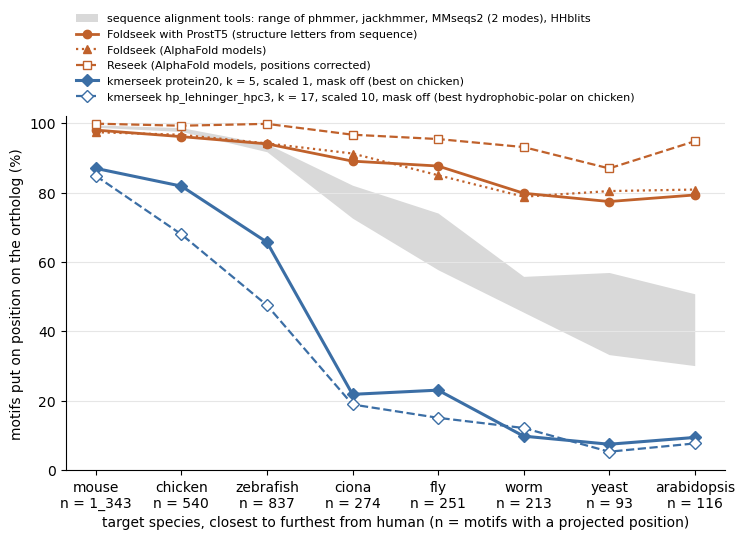

In [15]:
SEQUENCE_ARMS = ["hmmer3_phmmer", "hmmer3_jackhmmer", "mmseqs2_seqseq", "mmseqs2_iterative", "hhblits"]
# Chosen on chicken alone, so their share in the other species is not chosen on those motifs.
CHICKEN_BEST = "protein20.k5.lcfalse"
CHICKEN_BEST_HP = (
    SH.filter(pl.col("arm").is_in(CHOSEN) & pl.col("alphabet").str.starts_with("hp_"))
    .sort(CHECKS[-1], "arm", descending=[True, False])["arm"][0]
)
SHARE = (
    ALL_I.filter(pl.col("has_projection") & pl.col("scoreable"))
    .group_by("species", "arm")
    .agg(n=pl.len(), on_position=pl.col("ortholog_rank_on_position").is_not_null().sum())
    .with_columns(pct=100 * pl.col("on_position") / pl.col("n"))
)
best19 = (
    SHARE.filter(pl.col("arm").is_in(CHOSEN))
    .sort("pct", "arm", descending=[True, False])
    .group_by("species", maintain_order=True)
    .first()
    .select("species", best_of_19=pl.col("arm"), best_of_19_pct="pct")
)
wide = (
    SHARE.with_columns(
        tool=pl.col("arm").replace(
            {**COMPARATORS, CHICKEN_BEST: arm_label(CHICKEN_BEST), CHICKEN_BEST_HP: arm_label(CHICKEN_BEST_HP)}
        )
    )
    .filter(pl.col("arm").is_in(COMPARATOR_ARMS + [CHICKEN_BEST, CHICKEN_BEST_HP]))
    .pivot(on="species", index="tool", values="pct")
    .select("tool", *emu.COVER_SPECIES)
)
print("Motifs put on position on the 1:1 ortholog (%). Foldseek and Reseek: motifs whose")
print("ortholog has a matching AlphaFold model (n in the table below).")
print(wide.with_columns(pl.exclude("tool").round(1)))
print(best19.with_columns(pl.col("species").cast(pl.Enum(emu.COVER_SPECIES))).sort("species")
      .with_columns(pl.col("best_of_19_pct").round(1)))
print(SHARE.filter(pl.col("arm").is_in(["hmmer3_phmmer", "foldseek", "reseek"]))
      .pivot(on="species", index="arm", values="n").select("arm", *emu.COVER_SPECIES)
      .rename({"arm": "motifs counted (n)"}))
SHARE.write_csv(TAB / "253_on_position_by_species.csv")


def series(arm):
    d = SHARE.filter(pl.col("arm") == arm)
    return [d.filter(pl.col("species") == sp)["pct"][0] for sp in emu.COVER_SPECIES]


seq = np.array([series(a) for a in SEQUENCE_ARMS])
x = np.arange(len(emu.COVER_SPECIES))
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.fill_between(x, seq.min(axis=0), seq.max(axis=0), color="0.85", lw=0,
                label="sequence alignment tools: range of phmmer, jackhmmer, MMseqs2 (2 modes), HHblits")
ax.plot(x, series("prostt5"), color="#C0612B", lw=2, marker="o", label="Foldseek with ProstT5 (structure letters from sequence)")
ax.plot(x, series("foldseek"), color="#C0612B", lw=1.6, ls=":", marker="^", label="Foldseek (AlphaFold models)")
ax.plot(x, series("reseek"), color="#C0612B", lw=1.6, ls="--", marker="s", mfc="white",
        label="Reseek (AlphaFold models, positions corrected)")
ax.plot(x, series(CHICKEN_BEST), color="#3B6EA5", lw=2.2, marker="D",
        label=f"{arm_label(CHICKEN_BEST)} (best on chicken)")
ax.plot(x, series(CHICKEN_BEST_HP), color="#3B6EA5", lw=1.6, ls="--", marker="D", mfc="white",
        label=f"{arm_label(CHICKEN_BEST_HP)} (best hydrophobic-polar on chicken)")
n_seq = SHARE.filter(pl.col("arm") == "hmmer3_phmmer")
ax.set_xticks(x, [f"{sp}\nn = {n_seq.filter(pl.col('species') == sp)['n'][0]:_}" for sp in emu.COVER_SPECIES])
ax.set_ylim(0, 102)
ax.set_ylabel("motifs put on position on the ortholog (%)")
ax.set_xlabel("target species, closest to furthest from human (n = motifs with a projected position)")
ax.grid(axis="y", color="0.9", zorder=0)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_on_position_by_species.png", dpi=200, bbox_inches="tight")

kmerseek falls faster than every other search. protein20 with k = 5 puts 87.0% of motifs on
position in mouse, 81.9% in chicken and 65.7% in zebrafish, then 7.5% to 23.1% from Ciona to
Arabidopsis. The best hydrophobic-polar setting, hp_lehninger_hpc3 with k = 17 at scaled 10,
goes from 84.8% in mouse to 5.4% to 19.0% from Ciona to Arabidopsis. Even the best of the 19 settings in each species,
picked on the motifs it is scored on, reaches only 9.7% to 27.7% past zebrafish.

The sequence alignment tools also drop with distance, from 98.8% to 99.5% in mouse to 30.2%
to 50.9% in Arabidopsis. The structure searches drop least: in Arabidopsis, Foldseek with ProstT5
places 79.3%, Foldseek 80.9% and Reseek 94.8%. In every species, every comparison tool places at
least 30% of the motifs, and every kmerseek setting places at most 28% past zebrafish.

## 15. Each of the 19 kmerseek settings, by species

Share of motifs on position for every kmerseek setting in every species, sorted by the chicken
value. A setting that does well because it was chosen on chicken should fall back past chicken;
one that keeps its place across species is the better candidate for distant searches.

kmerseek, motifs put on position (%), sorted by the chicken value:
shape: (19, 9)
┌────────────────────────┬───────┬─────────┬───────────┬───────┬──────┬──────┬───────┬─────────────┐
│ kmerseek setting       ┆ mouse ┆ chicken ┆ zebrafish ┆ ciona ┆ fly  ┆ worm ┆ yeast ┆ arabidopsis │
│ ---                    ┆ ---   ┆ ---     ┆ ---       ┆ ---   ┆ ---  ┆ ---  ┆ ---   ┆ ---         │
│ str                    ┆ f64   ┆ f64     ┆ f64       ┆ f64   ┆ f64  ┆ f64  ┆ f64   ┆ f64         │
╞════════════════════════╪═══════╪═════════╪═══════════╪═══════╪══════╪══════╪═══════╪═════════════╡
│ protein20.k5.lcfalse   ┆ 87.0  ┆ 81.9    ┆ 65.7      ┆ 21.9  ┆ 23.1 ┆ 9.9  ┆ 7.5   ┆ 9.5         │
│ mmseqs12.k6.s5.lcfalse ┆ 90.1  ┆ 77.0    ┆ 57.7      ┆ 20.8  ┆ 23.5 ┆ 13.6 ┆ 9.7   ┆ 8.6         │
│ sdm12.k7.s2.lctrue     ┆ 84.0  ┆ 75.6    ┆ 56.9      ┆ 24.1  ┆ 26.3 ┆ 11.7 ┆ 7.5   ┆ 5.2         │
│ uniprot18.k5.s5.lcfals ┆ 91.9  ┆ 74.8    ┆ 56.8      ┆ 14.2  ┆ 13.1 ┆ 3.8  ┆ 3.2   ┆ 3.4         │
│ e      

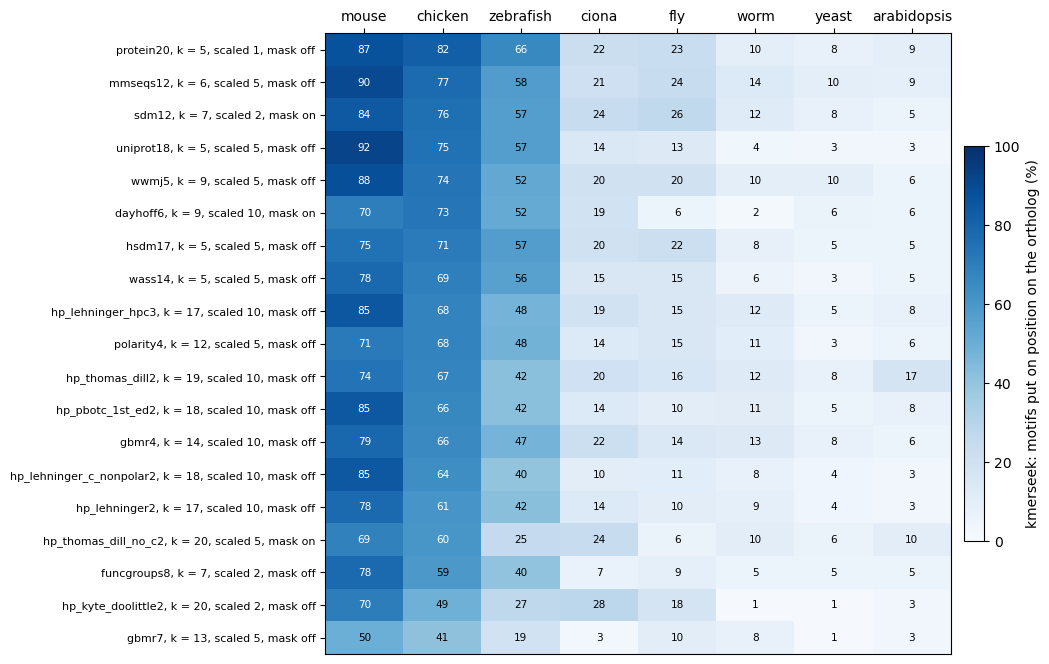

In [16]:
grid = (
    SHARE.filter(pl.col("arm").is_in(CHOSEN))
    .pivot(on="species", index="arm", values="pct")
    .select("arm", *emu.COVER_SPECIES)
    .sort("chicken", descending=True)
)
print("kmerseek, motifs put on position (%), sorted by the chicken value:")
print(grid.with_columns(pl.exclude("arm").round(1)).rename({"arm": "kmerseek setting"}))
grid.write_csv(TAB / "253_kmerseek_settings_by_species.csv")

vals = grid.select(emu.COVER_SPECIES).to_numpy()
fig, ax = plt.subplots(figsize=(8.5, 0.34 * grid.height + 1.6))
im = ax.imshow(vals, cmap="Blues", vmin=0, vmax=100, aspect="auto")
for r in range(vals.shape[0]):
    for c in range(vals.shape[1]):
        ax.text(c, r, f"{vals[r, c]:.0f}", ha="center", va="center", fontsize=7.5,
                color="white" if vals[r, c] > 60 else "black")
ax.set_xticks(range(len(emu.COVER_SPECIES)), emu.COVER_SPECIES)
ax.xaxis.tick_top()
ax.set_yticks(range(grid.height), [arm_label(a).removeprefix("kmerseek ") for a in grid["arm"]], fontsize=8)
cb = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cb.set_label("kmerseek: motifs put on position on the ortholog (%)")
fig.savefig(FIG / "253_kmerseek_settings_by_species.png", dpi=200, bbox_inches="tight")

No setting holds up past zebrafish. The best in Ciona is hp_kyte_doolittle2 with k = 20 (27.7%),
in fly sdm12 with k = 7 (26.3%), in worm and yeast mmseqs12 with k = 6 (13.6% and 9.7%), and in
Arabidopsis hp_thomas_dill2 with k = 19 (17.2%). hp_kyte_doolittle2 is second from last on
chicken (49.1%) and first on Ciona, but it places 0.9% in worm and 1.1% in yeast. Six different
settings are the best in the eight species, and the largest value past zebrafish is 27.7%.

## 16. Motifs only kmerseek puts on position, by species

The decision rule of the introduction, in every species: motifs that at least one of the 19
kmerseek settings puts on position and none of the eight comparison tools does. Pooling 19
settings makes this an upper bound.

Motifs with a projected position, by which searches put them on position
(kmerseek: any of the 19 settings; comparison tools: any of the eight):
shape: (8, 5)
┌─────────────┬────────┬─────────────────┬───────────────┬───────────┐
│ species     ┆ motifs ┆ comparison_tool ┆ only_kmerseek ┆ no_search │
│ ---         ┆ ---    ┆ ---             ┆ ---           ┆ ---       │
│ enum        ┆ u32    ┆ u32             ┆ u32           ┆ u32       │
╞═════════════╪════════╪═════════════════╪═══════════════╪═══════════╡
│ mouse       ┆ 1343   ┆ 1341            ┆ 0             ┆ 2         │
│ chicken     ┆ 540    ┆ 537             ┆ 0             ┆ 3         │
│ zebrafish   ┆ 837    ┆ 826             ┆ 0             ┆ 11        │
│ ciona       ┆ 274    ┆ 270             ┆ 0             ┆ 4         │
│ fly         ┆ 251    ┆ 242             ┆ 0             ┆ 9         │
│ worm        ┆ 213    ┆ 199             ┆ 0             ┆ 14        │
│ yeast       ┆ 93     ┆ 85              ┆ 0             ┆ 8

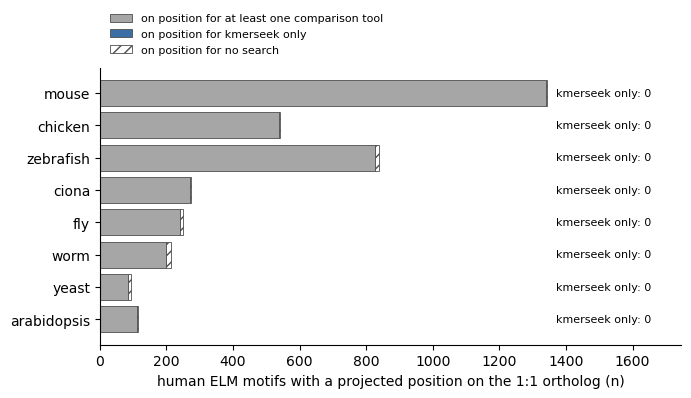

In [17]:
P = ALL_I.filter("has_projection").with_columns(hit=pl.col("ortholog_rank_on_position").is_not_null())
comp_hit = P.filter(pl.col("arm").is_in(COMPARATOR_ARMS)).group_by("species", "elm_instance").agg(any_comparator=pl.col("hit").any())
km_hit = P.filter(pl.col("arm").is_in(CHOSEN)).group_by("species", "elm_instance").agg(
    any_kmerseek=pl.col("hit").any(), n_kmerseek_settings=pl.col("hit").sum())
ONLY = (
    comp_hit.join(km_hit, on=["species", "elm_instance"])
    .group_by("species")
    .agg(
        motifs=pl.len(),
        comparison_tool=pl.col("any_comparator").sum(),
        only_kmerseek=(pl.col("any_kmerseek") & ~pl.col("any_comparator")).sum(),
        no_search=(~pl.col("any_kmerseek") & ~pl.col("any_comparator")).sum(),
    )
    .with_columns(pl.col("species").cast(pl.Enum(emu.COVER_SPECIES)))
    .sort("species")
)
print("Motifs with a projected position, by which searches put them on position")
print("(kmerseek: any of the 19 settings; comparison tools: any of the eight):")
print(ONLY)
ONLY.write_csv(TAB / "253_only_kmerseek_by_species.csv")

fig, ax = plt.subplots(figsize=(7.5, 3.6))
y = np.arange(ONLY.height)
left = np.zeros(ONLY.height)
for col, colour, hatch, name in [
    ("comparison_tool", "0.65", None, "on position for at least one comparison tool"),
    ("only_kmerseek", "#3B6EA5", None, "on position for kmerseek only"),
    ("no_search", "white", "///", "on position for no search"),
]:
    v = ONLY[col].to_numpy()
    ax.barh(y, v, left=left, color=colour, hatch=hatch, edgecolor="0.3", lw=0.6, label=name)
    left += v
for yi, k in zip(y, ONLY["only_kmerseek"]):
    ax.text(left.max() * 1.02, yi, f"kmerseek only: {k}", va="center", fontsize=8)
ax.set_yticks(y, ONLY["species"].cast(pl.String))
ax.invert_yaxis()
ax.set_xlim(0, 1.3 * left.max())
ax.set_xlabel("human ELM motifs with a projected position on the 1:1 ortholog (n)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, fontsize=8)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
fig.savefig(FIG / "253_only_kmerseek_by_species.png", dpi=200, bbox_inches="tight")


No species has such a motif. The comparison tools together put 91% to 100% of the motifs on
position in every species (85 of 93 in yeast to 1_341 of 1_343 in mouse). By the decision rule,
kmerseek adds nothing to these eight tools for moving ELM motifs to orthologs, in any of the
eight species.

## What this says

Against chicken, kmerseek puts a human ELM motif on its ortholog's position less often than every sequence tool: 81.9% for its best arm, against 96.1% to 98.7%. It also puts the ortholog low in its list, and it places no motif that the comparison tools miss.

Chicken is close enough to human that the sequence tools find almost every ortholog, which leaves kmerseek nothing to add. The farther species are searched next (#72), with one arm per alphabet chosen here. Their results, not these, are the fair measure of those arms.

The ranking score follows call length (section 11). That affects every result that uses the list order, including the cut to 1_000 targets.